In [1]:
import sys
!{sys.executable} -m pip install xgboost imbalanced-learn


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 582.1 kB/s eta 0:02:54
   ---------------------------------------- 1.0/101.7 MB 1.2 MB/s eta 0:01:24
    --------------------------------------- 1.6/101.7 MB 1.6 MB/s eta 0:01:05
   - -------------------------------------- 2.9/101.7 MB 2.5 MB/s eta 0:00:41
   -- ------------------------------------- 5.5/101.7 MB 4.1 MB/s eta 0:00:24
   -- ------------------------------------- 6.0/101.7 MB 4.4 MB/s eta 0:00:22
   --- -------------------

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, classification_report
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 加载数据
df = pd.read_csv(r'C:\Users\26817\Desktop\diabetes.csv')

print("数据形状：", df.shape)
print("\n列名：", df.columns.tolist())
print("\n患病分布：")
print(df['Outcome'].value_counts())
print(f"\n患病率：{df['Outcome'].mean()*100:.1f}%")
print("\n基本统计：")
df.describe().round(2)

数据形状： (768, 9)

列名： ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

患病分布：
Outcome
0    500
1    268
Name: count, dtype: int64

患病率：34.9%

基本统计：


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


In [9]:
# 1. 把不可能为0的字段的0值替换为NaN，然后用中位数填充
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_cols:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

print("零值处理完成，当前缺失值：")
print(df.isnull().sum())

# 2. 创建衍生特征（这是特征工程的核心）
# BMI分级
df['BMI_Grade'] = pd.cut(df['BMI'],
    bins=[0, 18.5, 25, 30, 100],
    labels=[0, 1, 2, 3]).astype(int)

# 血糖风险等级
df['Glucose_Risk'] = pd.cut(df['Glucose'],
    bins=[0, 100, 126, 200],
    labels=[0, 1, 2]).astype(int)

# 年龄分组
df['Age_Group'] = pd.cut(df['Age'],
    bins=[0, 30, 45, 60, 100],
    labels=[0, 1, 2, 3]).astype(int)

# 胰岛素抵抗指数（葡萄糖×胰岛素）
df['Insulin_Resistance'] = df['Glucose'] * df['Insulin']

# 妊娠风险（高龄多次妊娠）
df['Pregnancy_Risk'] = df['Pregnancies'] * df['Age']

print("\n特征工程完成，新增5个衍生特征")
print("当前特征数：", df.shape[1] - 1)
print("\n新特征预览：")
df[['BMI_Grade','Glucose_Risk','Age_Group',
    'Insulin_Resistance','Pregnancy_Risk']].head()

零值处理完成，当前缺失值：
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

特征工程完成，新增5个衍生特征
当前特征数： 13

新特征预览：


,BMI_Grade,Glucose_Risk,Age_Group,Insulin_Resistance,Pregnancy_Risk
0,3,2,2,18500.0,300
1,2,0,1,10625.0,31
2,1,2,1,22875.0,256
3,2,0,0,8366.0,21
4,3,2,1,23016.0,0


In [10]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# 切分特征和标签
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# 划分训练测试集（先划分，再对训练集做SMOTE）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"原始训练集患病比例：{y_train.mean()*100:.1f}%")

# SMOTE过采样（只对训练集做）
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"SMOTE后训练集患病比例：{y_train_sm.mean()*100:.1f}%")
print(f"SMOTE后训练集大小：{len(X_train_sm)}条")

# 标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

# 三个模型
models = {
    '逻辑回归': LogisticRegression(max_iter=1000, random_state=42),
    '随机森林': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':  XGBClassifier(n_estimators=100, random_state=42,
                               eval_metric='logloss')
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train_sm)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    results[name] = {'准确率': acc, 'AUC': auc,
                     'y_pred': y_pred, 'y_prob': y_prob}
    print(f"{name:8s}  准确率={acc*100:.1f}%  AUC={auc:.3f}")

best = max(results, key=lambda x: results[x]['AUC'])
print(f"\n最优模型：{best}，AUC={results[best]['AUC']:.3f}")

原始训练集患病比例：34.9%
SMOTE后训练集患病比例：50.0%
SMOTE后训练集大小：800条
逻辑回归      准确率=70.8%  AUC=0.793
随机森林      准确率=70.8%  AUC=0.824
XGBoost   准确率=72.1%  AUC=0.808

最优模型：随机森林，AUC=0.824


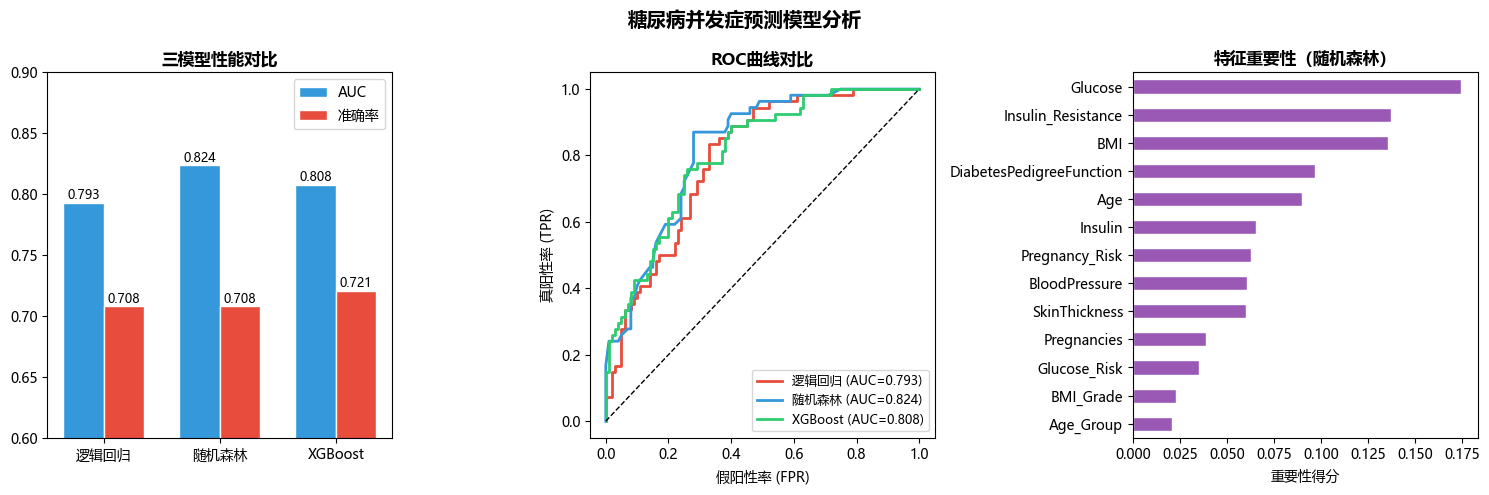

图表已保存


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 图1：三模型AUC对比
model_names = list(results.keys())
aucs = [results[m]['AUC'] for m in model_names]
accs = [results[m]['准确率'] for m in model_names]

x = np.arange(len(model_names))
width = 0.35
bars1 = axes[0].bar(x - width/2, aucs, width,
                     label='AUC', color='#3498DB', edgecolor='white')
bars2 = axes[0].bar(x + width/2, accs, width,
                     label='准确率', color='#E74C3C', edgecolor='white')
axes[0].set_title('三模型性能对比', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names)
axes[0].set_ylim(0.6, 0.9)
axes[0].legend()
for bar in bars1:
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.003,
                 f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2:
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.003,
                 f'{bar.get_height():.3f}', ha='center', fontsize=9)

# 图2：三模型ROC曲线对比
colors = ['#E74C3C', '#3498DB', '#2ECC71']
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    axes[1].plot(fpr, tpr, color=color, lw=2,
                 label=f'{name} (AUC={res["AUC"]:.3f})')
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_xlabel('假阳性率 (FPR)')
axes[1].set_ylabel('真阳性率 (TPR)')
axes[1].set_title('ROC曲线对比', fontweight='bold')
axes[1].legend(fontsize=9)

# 图3：随机森林特征重要性
rf_model = models['随机森林']
feat_imp = pd.Series(rf_model.feature_importances_,
                     index=X.columns).sort_values()
feat_imp.plot(kind='barh', ax=axes[2],
              color='#9B59B6', edgecolor='white')
axes[2].set_title('特征重要性（随机森林）', fontweight='bold')
axes[2].set_xlabel('重要性得分')

plt.suptitle('糖尿病并发症预测模型分析', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('diabetes_model_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("图表已保存")

In [12]:
print("=" * 50)
print("     糖尿病并发症预测项目 — 分析结论")
print("=" * 50)
print(f"""
【数据概况】
· 768条患者数据，原始8个特征，患病率34.9%
· 5个字段存在以0代替缺失值，用中位数填充

【特征工程】
· 新增5个衍生特征：BMI分级、血糖风险等级、
  年龄分组、胰岛素抵抗指数、妊娠风险指数
· 最终特征数：13个

【类别不均衡处理】
· 使用SMOTE过采样，患病比例从34.9%平衡至50%
· 训练集从614条扩充至800条

【模型对比结果】
· 逻辑回归：AUC=0.793
· XGBoost：  AUC=0.808
· 随机森林： AUC=0.824（最优）

【核心发现】
· 血糖（Glucose）是最强预测因子
· 自构造的胰岛素抵抗指数重要性排第二，
  验证了特征工程的有效性
· BMI和遗传因素（DiabetesPedigreeFunction）
  也是重要预测指标
""")
print("=" * 50)

     糖尿病并发症预测项目 — 分析结论

【数据概况】
· 768条患者数据，原始8个特征，患病率34.9%
· 5个字段存在以0代替缺失值，用中位数填充

【特征工程】
· 新增5个衍生特征：BMI分级、血糖风险等级、
  年龄分组、胰岛素抵抗指数、妊娠风险指数
· 最终特征数：13个

【类别不均衡处理】
· 使用SMOTE过采样，患病比例从34.9%平衡至50%
· 训练集从614条扩充至800条

【模型对比结果】
· 逻辑回归：AUC=0.793
· XGBoost：  AUC=0.808
· 随机森林： AUC=0.824（最优）

【核心发现】
· 血糖（Glucose）是最强预测因子
· 自构造的胰岛素抵抗指数重要性排第二，
  验证了特征工程的有效性
· BMI和遗传因素（DiabetesPedigreeFunction）
  也是重要预测指标

